# Datasets Combination

Merge all cleaned datasets into one

## A. Overview

List of datasets

- ACL_ICWSM_2018
- CrisisBench *(Combined)*
- CrisisLexT6
- CrisisLexT26
- CrisisMMD_V2
- CrisisNLP_R1
- Ecuador_Earthquake
- Eyewitness Messages
- HumAID
- ISCRAM2013
- SWDM2013

## B. Unified Dataset

### B.1. Merge

In [1]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd

import configuration
from src import dataset_settings, setup, data_utils

# from dotenv import load_dotenv
# load_dotenv()

all_files = [
    f
    for f in Path("../data/datasets").rglob("*.csv")
    if f != Path("../data/datasets/CrisisBench.csv")
]
print(f"Found {len(all_files)} CSV files in the datasets directory.")
for f in all_files:
    print(f" - {f}")

df_sep = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

Found 11 CSV files in the datasets directory.
 - ../data/datasets/CrisisLexT26.csv
 - ../data/datasets/Ecuador_Earthquake_2016.csv
 - ../data/datasets/SWDM2013.csv
 - ../data/datasets/CrisisNLP.csv
 - ../data/datasets/ISCRAM2013.csv
 - ../data/datasets/ACL_ICWSM_2018.csv
 - ../data/datasets/HumAID.csv
 - ../data/datasets/DSM.csv
 - ../data/datasets/CrisisLexT6.csv
 - ../data/datasets/CrisisMMD_v2.csv
 - ../data/datasets/eyewitness_messages.csv


In [2]:
df_sep['humanitarian_label'].unique()

array([nan, 'injured_or_dead_people', 'other_useful_information',
       'sympathy_and_emotional_support',
       'infrastructure_and_utilities_damage',
       'donation_needs_or_offers_or_volunteering_services',
       'caution_and_advice', 'displaced_people_and_evacuations',
       'missing_trapped_or_found_people', 'not_related_or_irrelevant',
       'Caution and advice', 'Information source',
       'Donations of money, goods or services', 'Casualties and damage',
       'Unknown', 'People missing, found or seen',
       'rescue_volunteering_or_donation_effort', 'sympathy_and_support',
       'infrastructure_and_utility_damage', 'other_relevant_information',
       'not_humanitarian', 'requests_or_urgent_needs',
       'missing_or_found_people', 'affected_individuals', 'unclassified'],
      dtype=object)

### CrisisBench

The CrisisBench dataset combines
- CrisisLex
- CrisisNLP
- SWDM13
- ISCRAM13
- DRD
- DSM
- CrisisMMD
- AIDR

The author did some cleaning and mapping, then we remove them to keep original tweet text.

In [3]:
df_cb = pd.read_csv('../data/datasets/CrisisBench.csv')

/tmp/ipykernel_3140/2322361637.py:1: DtypeWarning: Columns (0: humanitarian_label, 1: original_humanitarian_label) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cb = pd.read_csv('../data/datasets/CrisisBench.csv')


In [4]:
print(f"df_cb: {len(df_cb)} rows")
print(f"df_sep: {len(df_sep)} rows")

df_cb: 151999 rows
df_sep: 235085 rows


In [5]:
included_datasets = [
    "DRD-FigureEight-Multimedia",
    "AIDR_system",
    # these datasets have been edited, use the original ones instead
    # "CrisisLexT26",
    # "CrisisLexT6",
    # "CrisisNLP-volunteers",
    # "CrisisNLP-CF",
    # "SWDM13",
    # "ISCRAM13",
    # "DSM-CF",
    # "CrisisMMD",
]
df_cb_unq_ids = df_cb[df_cb["dataset"].isin(included_datasets)]['tweet_id']

In [6]:
len(df_cb_unq_ids)

28835

In [7]:
# print(df.duplicated(subset=['tweet_id']).sum())
# print(df.duplicated(subset=['tweet_text']).sum())

# df = df[~df['tweet_id'].isin(df_cb['tweet_id'])]
# df = df[~df['tweet_text'].isin(df_cb['tweet_text'])]
df = pd.concat([df_sep, df_cb[df_cb['tweet_id'].isin(df_cb_unq_ids)]], ignore_index=True)
# df = pd.concat([df, df_cb], ignore_index=True)

# df['tweet_id'] = df['tweet_id'].astype(str)

In [8]:
print(f"df: {len(df)} rows")

df: 263920 rows


### B.2. Remove Duplicated

In [9]:
df_dup_id = df[df.duplicated(subset=['tweet_id'], keep=False)]
print(f"Number of duplicate tweet_ids: {len(df_dup_id)}")

df_dup_text = df[df.duplicated(subset=['tweet_text'], keep=False)]
print(f"Number of duplicate tweet_texts: {len(df_dup_text)}")

Number of duplicate tweet_ids: 34995


Number of duplicate tweet_texts: 36100


In [10]:
set(df_dup_id['tweet_id']).issubset(set(df_dup_text['tweet_id']))

False

In [11]:
df = df.drop_duplicates(subset=['tweet_id']).drop_duplicates(subset=['tweet_text'])
print(f"df: {len(df)} rows")

df: 244403 rows


### B.3. Re-order columns

In [12]:
df = df[['tweet_id', 'tweet_text', 'informative', 'humanitarian_label', 'dataset',
         'event_type', 'year', 'event_name', 'country', 'url', 'original_informative_label', 'original_humanitarian_label', 'meta']]

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 244403 entries, 0 to 263919
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   tweet_id                     244403 non-null  object 
 1   tweet_text                   244403 non-null  str    
 2   informative                  244403 non-null  bool   
 3   humanitarian_label           156151 non-null  object 
 4   dataset                      244403 non-null  str    
 5   event_type                   244403 non-null  str    
 6   year                         204989 non-null  float64
 7   event_name                   219999 non-null  object 
 8   country                      41506 non-null   str    
 9   url                          4173 non-null    str    
 10  original_informative_label   95175 non-null   object 
 11  original_humanitarian_label  166899 non-null  object 
 12  meta                         200913 non-null  object 
dtypes: bool(1), flo

In [14]:
df.head()

,tweet_id,tweet_text,informative,humanitarian_label,dataset,event_type,year,event_name,country,url,original_informative_label,original_humanitarian_label,meta
0,211040709124440064,#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #...,False,NaN,CrisisLexT26,wildfire,2012.0,2012 Colorado Wildfires,NaN,NaN,Not related,Not labeled,{'file_name': '2012_Colorado_wildfires/2012_Co...
1,211111710294163457,RT @Jack4Ward: Get in on the fun every Thursda...,False,NaN,CrisisLexT26,wildfire,2012.0,2012 Colorado Wildfires,NaN,NaN,Not related,Not labeled,{'file_name': '2012_Colorado_wildfires/2012_Co...
2,211157222699433985,Welcome to our newest STUDENTathlete- Reagan B...,False,NaN,CrisisLexT26,wildfire,2012.0,2012 Colorado Wildfires,NaN,NaN,Not related,Not labeled,{'file_name': '2012_Colorado_wildfires/2012_Co...
3,211162553659830272,Denver Post: #Colorado governor signs bill cre...,False,NaN,CrisisLexT26,wildfire,2012.0,2012 Colorado Wildfires,NaN,NaN,Not related,Not labeled,{'file_name': '2012_Colorado_wildfires/2012_Co...
4,211216962162933761,Pretty sure I'm going to live in Manitou Sprin...,False,NaN,CrisisLexT26,wildfire,2012.0,2012 Colorado Wildfires,NaN,NaN,Not related,Not labeled,{'file_name': '2012_Colorado_wildfires/2012_Co...


### B.3. NaN values

In [15]:
nan_event_names = df[df['event_name'].isna()]

print(f"Number of rows with NaN event_name: {len(nan_event_names)}")
print(nan_event_names['dataset'].value_counts())

Number of rows with NaN event_name: 24404
dataset
eyewitness_messages          13801
disasters_on_social_media    10603
Name: count, dtype: int64


### B.4. Event names

In [16]:
event_name_mapping = {
    "Cyclone Idai": "2019 Cyclone Idai",
    "Ecuador Earthquake 2016": "2016 Ecuador Earthquake",
    "Hurricane Dorian": "2019 Hurricane Dorian",
    "Hurricane Florence": "2018 Hurricane Florence",
    "Hurricane Harvey": "2017 Hurricane Harvey",
    "Hurricane Irma": "2017 Hurricane Irma",
    "Hurricane Maria": "2017 Hurricane Maria",
    "Hurricane Matthew": "2016 Hurricane Matthew",
    "Midwestern US Floods": "2019 Midwestern US Floods",
    "california_wildfires": "2017 California Wildfires",
    # "disaster_events": np.nan,
    "hurricane_harvey": "2017 Hurricane Harvey",
    "hurricane_irma": "2017 Hurricane Irma",
    "hurricane_maria": "2017 Hurricane Maria",
    "iraq_iran_earthquake": "2017 Iraq-Iran Earthquake",
    "mexico_earthquake": "2017 Puebla Mexico Earthquake",
    "srilanka_floods": "2017 Sri Lanka Floods",
}

# map the event_name to if it maches the mapping, otherwise keep it as is
df['event_name'] = df['event_name'].map(lambda x: event_name_mapping.get(x, x))
print(df['event_name'].unique())

# df['event_name'] = df['event_name'].map(event_name_mapping)
# print(df['event_name'].unique())


<ArrowStringArray>
[         '2012 Colorado Wildfires',       '2012 Costa Rica Earthquake',
        '2012 Guatemala Earthquake',           '2012 Italy Earthquakes',
          '2012 Philippines Floods',               '2012 Typhoon Pablo',
              '2013 Alberta Floods',          '2013 Australia Bushfire',
            '2013 Bohol Earthquake',             '2013 Colorado Floods',
               '2013 Manila Floods',           '2013 Queensland Floods',
               '2013 Russia Meteor',             '2013 Sardinia Floods',
             '2013 Typhoon Yolanda',          '2016 Ecuador Earthquake',
              '2011 Joplin tornado',       '2014 California Earthquake',
            '2014 Chile Earthquake',      '2014 Hurricane Odile Mexico',
             '2014 Iceland Volcano', '2014 Philippines Typhoon Hagupit',
                 '2015 Cyclone Pam',            '2015 Nepal Earthquake',
             'Landslides Worldwide',         '2013 Pakistan Earthquake',
                '2014 India Floo

## C. Humanitarian Label Mapping

In [17]:
print(df['humanitarian_label'].unique())

[nan 'injured_or_dead_people' 'other_useful_information'
 'sympathy_and_emotional_support' 'infrastructure_and_utilities_damage'
 'donation_needs_or_offers_or_volunteering_services' 'caution_and_advice'
 'displaced_people_and_evacuations' 'missing_trapped_or_found_people'
 'not_related_or_irrelevant' 'Caution and advice' 'Information source'
 'Donations of money, goods or services' 'Casualties and damage' 'Unknown'
 'People missing, found or seen' 'rescue_volunteering_or_donation_effort'
 'sympathy_and_support' 'infrastructure_and_utility_damage'
 'other_relevant_information' 'not_humanitarian'
 'requests_or_urgent_needs' 'missing_or_found_people'
 'affected_individuals' 'unclassified' 'requests_or_needs'
 'affected_individual' 'donation_and_volunteering'
 'missing_and_found_people' 'displaced_and_evacuations']


In [18]:
# map the humanitarian labels to the unified set of labels
df['humanitarian_label'] = df['humanitarian_label'].map(dataset_settings.humanitarian_labels_mapping)
print(df['humanitarian_label'].unique())

<ArrowStringArray>
[                                     nan,
                 'injured_or_dead_people',
             'other_relevant_information',
                   'sympathy_and_support',
      'infrastructure_and_utility_damage',
 'rescue_volunteering_or_donation_effort',
       'displaced_people_and_evacuations',
        'missing_trapped_or_found_people',
              'not_related_or_irrelevant',
                'unknown_or_unclassified',
                       'not_humanitarian',
                      'requests_or_needs',
                   'affected_individuals']
Length: 13, dtype: str


# D. Review

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 244403 entries, 0 to 263919
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   tweet_id                     244403 non-null  object 
 1   tweet_text                   244403 non-null  str    
 2   informative                  244403 non-null  bool   
 3   humanitarian_label           148796 non-null  str    
 4   dataset                      244403 non-null  str    
 5   event_type                   244403 non-null  str    
 6   year                         204989 non-null  float64
 7   event_name                   219999 non-null  str    
 8   country                      41506 non-null   str    
 9   url                          4173 non-null    str    
 10  original_informative_label   95175 non-null   object 
 11  original_humanitarian_label  166899 non-null  object 
 12  meta                         200913 non-null  object 
dtypes: bool(1), flo

<Axes: ylabel='dataset'>

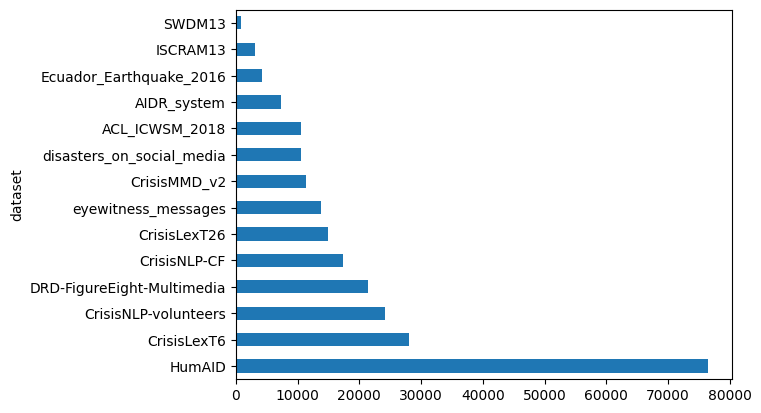

In [20]:
df['dataset'].value_counts().plot(kind='barh')

<Axes: ylabel='humanitarian_label'>

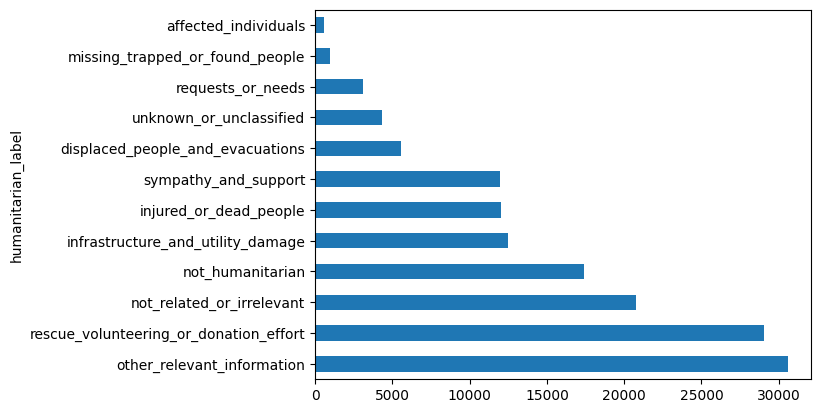

In [21]:
df['humanitarian_label'].value_counts().plot(kind='barh')

informative
True     170034
False     74369
Name: count, dtype: int64

<Axes: xlabel='informative'>

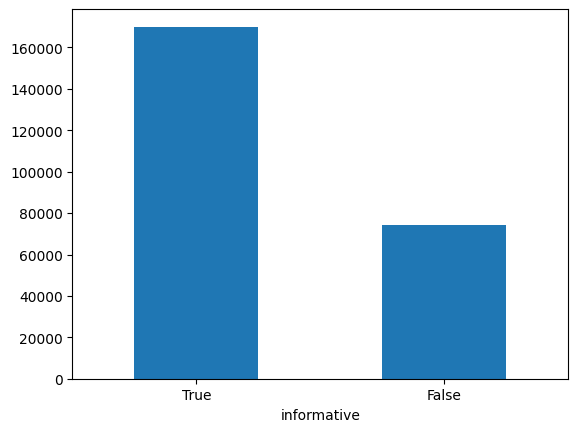

In [22]:
display(df['informative'].value_counts(dropna=False))
df['informative'].value_counts(dropna=False).plot(kind='bar', rot=0)

In [23]:
df = df.sample(frac=1, random_state=setup.RANDOM_SEED).reset_index(drop=True)

In [24]:
df.head()

,tweet_id,tweet_text,informative,humanitarian_label,dataset,event_type,year,event_name,country,url,original_informative_label,original_humanitarian_label,meta
0,1030399710626889729,Its really makes hurt #KeralaFloods2018 . Maki...,True,sympathy_and_support,HumAID,flood,2018.0,2018 Kerala Floods,NaN,NaN,NaN,sympathy_and_support,"{'file_name': 'kerala_floods_2018_test.tsv', '..."
1,1065300638932692992,"RT @SFGate: Camp Fire death toll climbs to 81,...",True,injured_or_dead_people,HumAID,wildfire,2018.0,2018 California Wildfires,NaN,NaN,NaN,injured_or_dead_people,{'file_name': 'california_wildfires_2018_test....
2,297230411636035584,Another Friday night on the computrainer. http...,False,NaN,ACL_ICWSM_2018,flood,2013.0,2013 Queensland Floods,NaN,NaN,not_relevant,NaN,"{""file_name"": ""queensland/2013_Queensland_Floo..."
3,847299025439150081,Cyclone Debbie: Queensland's big wet brings wi...,True,NaN,eyewitness_messages,storm,2017.0,NaN,NaN,NaN,NaN,NaN,{'file_name': 'hurricanes_eyewitness_crowdflow...
4,220663373652701184,no fireworks no explosions no exceptions i wan...,True,NaN,CrisisLexT26,wildfire,2012.0,2012 Colorado Wildfires,NaN,NaN,Related - but not informative,Sympathy and support,{'file_name': '2012_Colorado_wildfires/2012_Co...


#### Export to csv

In [25]:
frac = data_utils.get_data_disaster_fraction()
disaster_path = Path("..") / "data" / "disaster"
disaster_path.parent.mkdir(parents=True, exist_ok=True)

frac_path = disaster_path / str(frac)
frac_path.mkdir(parents=True, exist_ok=True)
print(f"Sampling {frac:.2%} of the dataset for disaster data...")

Sampling 2.50% of the dataset for disaster data...


##### Informative

In [26]:
df_informative = df[[ "tweet_text", "informative"]].reset_index(drop=True)

df_informative.to_csv(
    disaster_path / "informative.csv",
    quoting=csv.QUOTE_ALL,
    index=False,
)

df_informative.sample(
    frac=frac, random_state=setup.RANDOM_SEED
).reset_index(
    drop=True
).to_csv(
    frac_path / f"informative.csv",
    quoting=csv.QUOTE_ALL,
    index=False,
)

##### Humanitarian

In [27]:
df_humanitarian = df[~df["humanitarian_label"].isnull()][
    ["tweet_text", "humanitarian_label"]
].reset_index(drop=True)

df_humanitarian.to_csv(
    disaster_path / "humanitarian.csv",
    quoting=csv.QUOTE_ALL,
    index=False,
)

df_humanitarian.sample(frac=frac, random_state=setup.RANDOM_SEED).reset_index(
    drop=True
).to_csv(
    frac_path / f"humanitarian.csv",
    quoting=csv.QUOTE_ALL,
    index=False,
)